In [8]:
# =====================================================
# Supervised Learning Project - Regression & Classification
# Run in Jupyter Notebook
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB


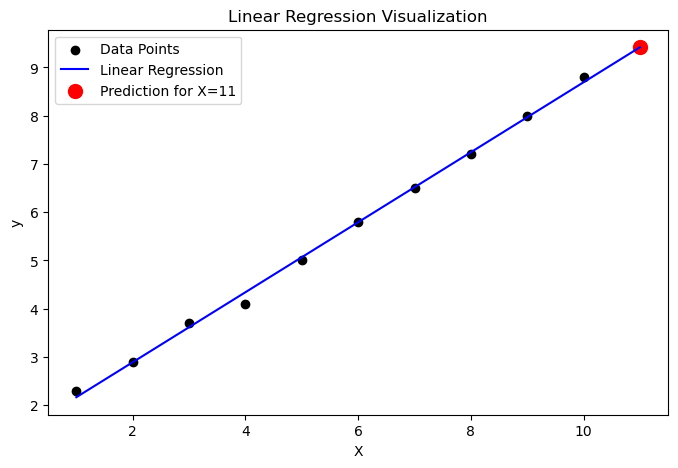

In [9]:

# -----------------------------------------------------
# 1️⃣ Regression Example Data
X_reg = np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)
y_reg = np.array([2.3,2.9,3.7,4.1,5.0,5.8,6.5,7.2,8.0,8.8])

# Linear Regression
# ==================1. Linear Regression (Regression បន្ទាត់)===================
# អ្វីដែលវាធ្វើ: ទាយតម្លៃជាចំនួន (continuous value) ដោយសមីការ linear.
# ឧទាហរណ៍: ទាយតម្លៃផ្ទះ ឬ ពិន្ទុសិស្ស។
# គន្លឹះ: assume ទំនាក់ទំនង X → Y ជាបន្ទាត់។

# Train Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_reg, y_reg)

# Predict for plotting
X_plot = np.linspace(1,11,100).reshape(-1,1)
y_plot = lin_reg.predict(X_plot)

# Visualization
plt.figure(figsize=(8,5))
plt.scatter(X_reg, y_reg, color='black', label='Data Points')  # Actual data
plt.plot(X_plot, y_plot, color='blue', label='Linear Regression')  # Regression line
plt.scatter([11], lin_reg.predict([[11]]), color='red', s=100, label='Prediction for X=11')  # Prediction
plt.title("Linear Regression Visualization")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


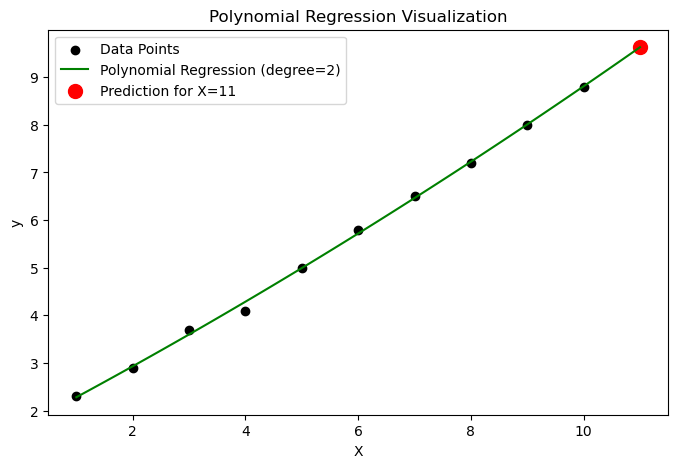

In [10]:

# Polynomial Regression
# ==================2. Polynomial Regression (Regression ពហុខ្ទង់)==============
# អ្វីដែលវាធ្វើ: ទាយតម្លៃដែលមាន ទំនាក់ទំនងមិនបន្ទាត់ ដោយបន្ថែម powers (x², x³...)។
# ឧទាហរណ៍: ទាយលទ្ធផលស៊ីធីណាមិច (growth curves, trend curves)។
# គន្លឹះ: ใช้เมื่อ Linear Regression មិនគ្រប់គ្រាន់សម្រាប់ fit data។
# Example data
X_reg = np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)
y_reg = np.array([2.3,2.9,3.7,4.1,5.0,5.8,6.5,7.2,8.0,8.8])

# Polynomial Regression (degree 2)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_reg)
poly_reg = LinearRegression()
poly_reg.fit(X_poly, y_reg)

# Predict for plotting
X_plot = np.linspace(1,11,100).reshape(-1,1)
y_plot = poly_reg.predict(poly.transform(X_plot))

# Visualization
plt.figure(figsize=(8,5))
plt.scatter(X_reg, y_reg, color='black', label='Data Points')  # Actual data
plt.plot(X_plot, y_plot, color='green', label='Polynomial Regression (degree=2)')  # Regression curve
plt.scatter([11], poly_reg.predict(poly.transform([[11]])), color='red', s=100, label='Prediction for X=11')  # Prediction
plt.title("Polynomial Regression Visualization")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

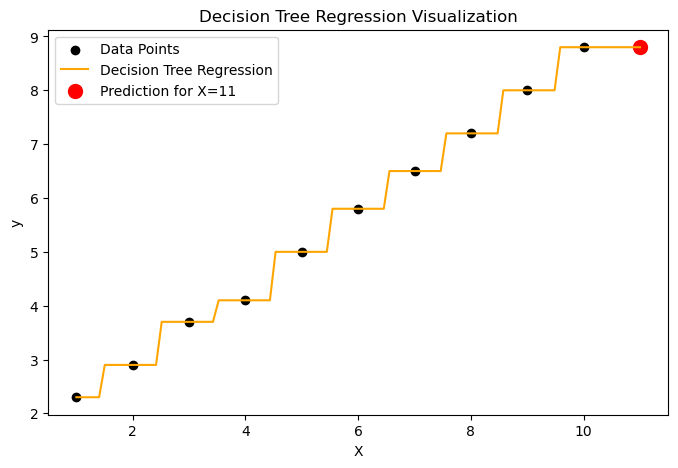

In [11]:

# Decision Tree Regressor
# ==================3. Decision Tree Regressor (Regression ដើមឈើសម្រេច)========
# អ្វីដែលវាធ្វើ: បំបែកទិន្នន័យជារៀងៗ ដើម្បីទាយតម្លៃ។
# ឧទាហរណ៍: ទាយតម្លៃផ្ទះដោយប្រើលក្ខខណ្ឌ “size > 50 sqm → price = 100k$”។
# គន្លឹះ: អាចដោះស្រាយ non-linear relationships បានល្អ។
# Example data
X_reg = np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)
y_reg = np.array([2.3,2.9,3.7,4.1,5.0,5.8,6.5,7.2,8.0,8.8])

# Decision Tree Regression
dt_reg = DecisionTreeRegressor()
dt_reg.fit(X_reg, y_reg)

# Predict for plotting
X_plot = np.linspace(1,11,100).reshape(-1,1)
y_plot = dt_reg.predict(X_plot)

# Visualization
plt.figure(figsize=(8,5))
plt.scatter(X_reg, y_reg, color='black', label='Data Points')  # Actual data
plt.plot(X_plot, y_plot, color='orange', label='Decision Tree Regression')  # Step-like curve
plt.scatter([11], dt_reg.predict([[11]]), color='red', s=100, label='Prediction for X=11')  # Prediction
plt.title("Decision Tree Regression Visualization")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


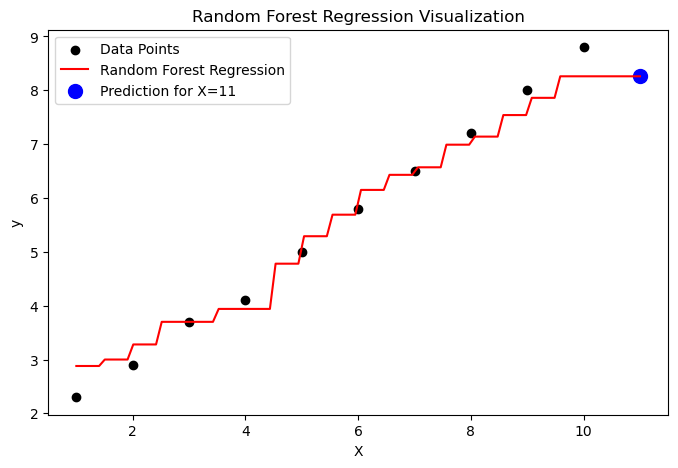

In [12]:

# Random Forest Regressor
# ==================4. Random Forest Regressor (Regression ពហុដើមឈើ)==========
# អ្វីដែលវាធ្វើ: ប្រើ decision tree ជាច្រើន ហើយយក លទ្ធផលមធ្យម។
# ឧទាហរណ៍: ទាយតម្លៃផ្ទះ ដោយបញ្ចូល tree ជាច្រើន ដើម្បីបានទាយតម្លៃល្អបំផុត។
# គន្លឹះ: ការប្រៀបធៀប tree ជាច្រើន ជួយកាត់បន្ថយ overfitting។
# Example data
X_reg = np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)
y_reg = np.array([2.3,2.9,3.7,4.1,5.0,5.8,6.5,7.2,8.0,8.8])

# Random Forest Regression
rf_reg = RandomForestRegressor(n_estimators=10, random_state=42)
rf_reg.fit(X_reg, y_reg)

# Predict for plotting
X_plot = np.linspace(1,11,100).reshape(-1,1)
y_plot = rf_reg.predict(X_plot)

# Visualization
plt.figure(figsize=(8,5))
plt.scatter(X_reg, y_reg, color='black', label='Data Points')  # Actual data
plt.plot(X_plot, y_plot, color='red', label='Random Forest Regression')  # Averaged curve
plt.scatter([11], rf_reg.predict([[11]]), color='blue', s=100, label='Prediction for X=11')  # Prediction
plt.title("Random Forest Regression Visualization")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


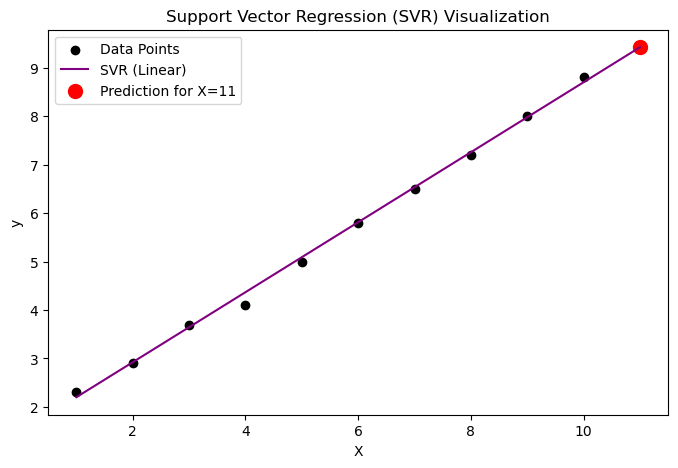

In [13]:

# Support Vector Regressor (SVR)
# ===================5. Support Vector Regressor (SVR)========================
# អ្វីដែលវាធ្វើ: ប្រើ hyperplane ដើម្បី fit data regression.
# ឧទាហរណ៍: ទាយតម្លៃ stock price ឬ growth trend។
# គន្លឹះ: kernel trick អាចប្រើសម្រាប់ non-linear regression បាន។
# Example data
X_reg = np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)
y_reg = np.array([2.3,2.9,3.7,4.1,5.0,5.8,6.5,7.2,8.0,8.8])

# Support Vector Regression (linear kernel)
svr = SVR(kernel='linear')
svr.fit(X_reg, y_reg)

# Predict for plotting
X_plot = np.linspace(1,11,100).reshape(-1,1)
y_plot = svr.predict(X_plot)

# Visualization
plt.figure(figsize=(8,5))
plt.scatter(X_reg, y_reg, color='black', label='Data Points')  # Actual data
plt.plot(X_plot, y_plot, color='purple', label='SVR (Linear)')  # Regression line
plt.scatter([11], svr.predict([[11]]), color='red', s=100, label='Prediction for X=11')  # Prediction
plt.title("Support Vector Regression (SVR) Visualization")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


Logistic Regression Prediction [5,78]: [1]


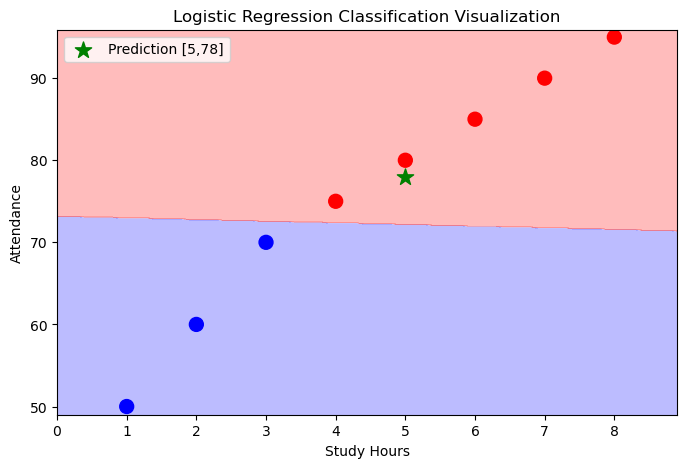

In [14]:

# -----------------------------------------------------
# 2️⃣ Classification Example Data
X_class = np.array([[1,50],[2,60],[3,70],[4,75],[5,80],[6,85],[7,90],[8,95]])
y_class = np.array([0,0,0,1,1,1,1,1])  # 0=Fail, 1=Pass

# Logistic Regression
# ====================6. Logistic Regression (Regression Logistic)===========
# អ្វីដែលវាធ្វើ: ទាយ label (binary/multi-class) ដោយទម្លាក់ probability 0–1។
# ឧទាហរណ៍: Spam detection, pass/fail prediction.
# គន្លឹះ: output = probability → ទៅកាន់ label 0 ឬ 1។
# Example classification data
X_class = np.array([[1,50],[2,60],[3,70],[4,75],[5,80],[6,85],[7,90],[8,95]])
y_class = np.array([0,0,0,1,1,1,1,1])  # 0=Fail, 1=Pass

# Train Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_class, y_class)

# Prediction for example
pred_example = log_reg.predict([[5,78]])
print("Logistic Regression Prediction [5,78]:", pred_example)

# Visualization (decision boundary)
x_min, x_max = X_class[:,0].min()-1, X_class[:,0].max()+1
y_min, y_max = X_class[:,1].min()-1, X_class[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
Z = log_reg.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
plt.scatter(X_class[:,0], X_class[:,1], c=y_class, cmap='bwr', s=100)
plt.scatter([5], [78], color='green', s=150, marker='*', label='Prediction [5,78]')
plt.title("Logistic Regression Classification Visualization")
plt.xlabel("Study Hours")
plt.ylabel("Attendance")
plt.legend()
plt.show()


Decision Tree Classification Prediction [5,78]: [1]


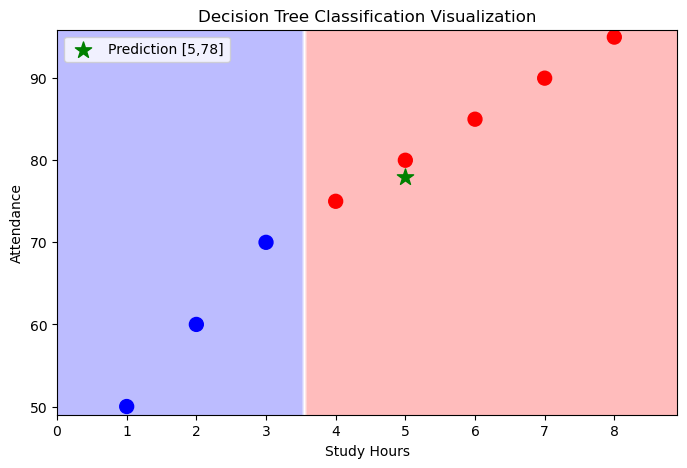

In [15]:

# Decision Tree Classifier
# =====================7. Decision Tree Classifier=======================
# អ្វីដែលវាធ្វើ: បំបែកទិន្នន័យជារង្វង់ ដើម្បីសម្រេច label។
# ឧទាហរណ៍: ទាយថាសិស្សជាប់/អត់ ប្រើ study hours និង attendance.
# គន្លឹះ: ច្បាស់ និងងាយយល់, អាច visualize rules បាន។
# Example classification data
X_class = np.array([[1,50],[2,60],[3,70],[4,75],[5,80],[6,85],[7,90],[8,95]])
y_class = np.array([0,0,0,1,1,1,1,1])  # 0=Fail, 1=Pass

# Train Decision Tree Classifier
dt_clf = DecisionTreeClassifier()
dt_clf.fit(X_class, y_class)

# Prediction example
pred_example = dt_clf.predict([[5,78]])
print("Decision Tree Classification Prediction [5,78]:", pred_example)

# Visualization (decision boundary)
x_min, x_max = X_class[:,0].min()-1, X_class[:,0].max()+1
y_min, y_max = X_class[:,1].min()-1, X_class[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
Z = dt_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
plt.scatter(X_class[:,0], X_class[:,1], c=y_class, cmap='bwr', s=100)
plt.scatter([5], [78], color='green', s=150, marker='*', label='Prediction [5,78]')
plt.title("Decision Tree Classification Visualization")
plt.xlabel("Study Hours")
plt.ylabel("Attendance")
plt.legend()
plt.show()


Random Forest Classification Prediction [5,78]: [1]


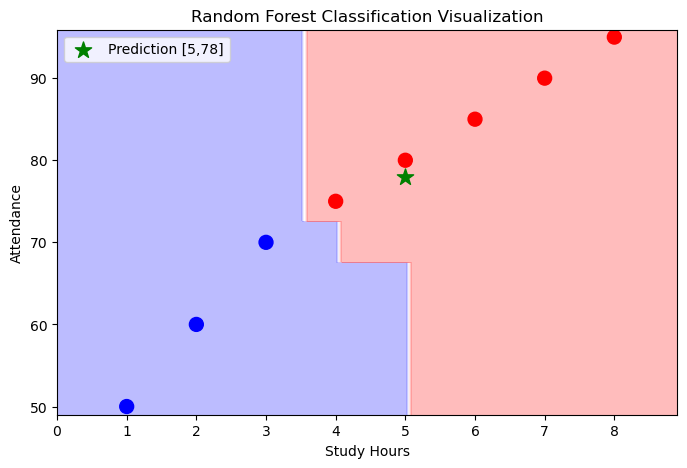

In [16]:

# Random Forest Classifier
# ========================8. Random Forest Classifier======================
# អ្វីដែលវាធ្វើ: ប្រើ decision tree ជាច្រើន ហើយយក label ច្រើនជាងគេ (majority vote)។
# ឧទាហរណ៍: Fraud detection, customer classification.
# គន្លឹះ: កាត់បន្ថយ overfitting និង stable result។

# Example classification data
X_class = np.array([[1,50],[2,60],[3,70],[4,75],[5,80],[6,85],[7,90],[8,95]])
y_class = np.array([0,0,0,1,1,1,1,1])  # 0=Fail, 1=Pass

# Train Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=10, random_state=42)
rf_clf.fit(X_class, y_class)

# Prediction example
pred_example = rf_clf.predict([[5,78]])
print("Random Forest Classification Prediction [5,78]:", pred_example)

# Visualization (decision boundary)
x_min, x_max = X_class[:,0].min()-1, X_class[:,0].max()+1
y_min, y_max = X_class[:,1].min()-1, X_class[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
Z = rf_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
plt.scatter(X_class[:,0], X_class[:,1], c=y_class, cmap='bwr', s=100)
plt.scatter([5], [78], color='green', s=150, marker='*', label='Prediction [5,78]')
plt.title("Random Forest Classification Visualization")
plt.xlabel("Study Hours")
plt.ylabel("Attendance")
plt.legend()
plt.show()


kNN Prediction [5,78]: [1]


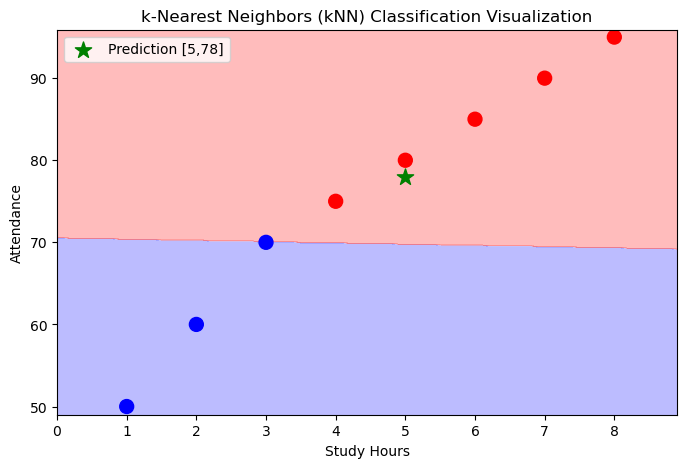

In [17]:

# k-Nearest Neighbors
# 9. k-Nearest Neighbors (kNN)
# អ្វីដែលវាធ្វើ: ទាយ label ដោយមើល neighbors ជិតជាង k នាក់។
# ឧទាហរណ៍: Classification based on similarity (e.g., handwriting recognition).
# គន្លឹះ: អាស្រ័យលើ distance metric (Euclidean, Manhattan)។
# Example classification data
X_class = np.array([[1,50],[2,60],[3,70],[4,75],[5,80],[6,85],[7,90],[8,95]])
y_class = np.array([0,0,0,1,1,1,1,1])  # 0=Fail, 1=Pass

# Train kNN Classifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_class, y_class)

# Prediction example
pred_example = knn.predict([[5,78]])
print("kNN Prediction [5,78]:", pred_example)

# Visualization (decision boundary)
x_min, x_max = X_class[:,0].min()-1, X_class[:,0].max()+1
y_min, y_max = X_class[:,1].min()-1, X_class[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
plt.scatter(X_class[:,0], X_class[:,1], c=y_class, cmap='bwr', s=100)
plt.scatter([5], [78], color='green', s=150, marker='*', label='Prediction [5,78]')
plt.title("k-Nearest Neighbors (kNN) Classification Visualization")
plt.xlabel("Study Hours")
plt.ylabel("Attendance")
plt.legend()
plt.show()


SVM Prediction [5,78]: [1]


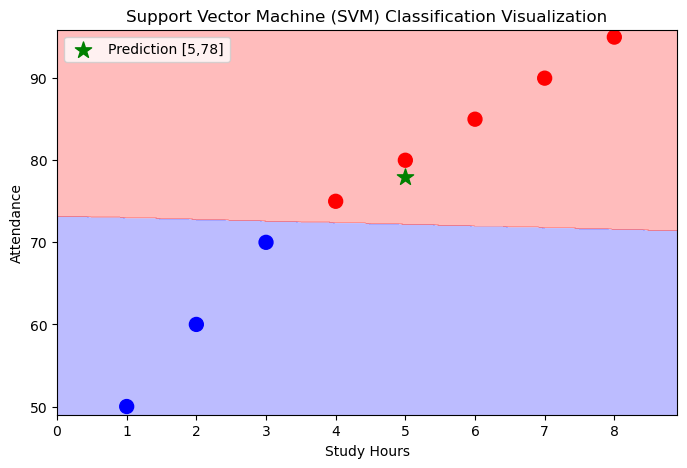

In [18]:

# Support Vector Machine (SVM)
# 10. Support Vector Machine (SVM)
# អ្វីដែលវាធ្វើ: បែងចែក label ដោយ hyperplane.
# ឧទាហរណ៍: Spam detection, face recognition.
# គន្លឹះ: kernel trick អាចប្រើសម្រាប់ non-linear classification.
# Example classification data
X_class = np.array([[1,50],[2,60],[3,70],[4,75],[5,80],[6,85],[7,90],[8,95]])
y_class = np.array([0,0,0,1,1,1,1,1])  # 0=Fail, 1=Pass

# Train SVM Classifier (linear kernel)
svm_clf = SVC(kernel='linear')
svm_clf.fit(X_class, y_class)

# Prediction example
pred_example = svm_clf.predict([[5,78]])
print("SVM Prediction [5,78]:", pred_example)

# Visualization (decision boundary)
x_min, x_max = X_class[:,0].min()-1, X_class[:,0].max()+1
y_min, y_max = X_class[:,1].min()-1, X_class[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
Z = svm_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
plt.scatter(X_class[:,0], X_class[:,1], c=y_class, cmap='bwr', s=100)
plt.scatter([5], [78], color='green', s=150, marker='*', label='Prediction [5,78]')
plt.title("Support Vector Machine (SVM) Classification Visualization")
plt.xlabel("Study Hours")
plt.ylabel("Attendance")
plt.legend()
plt.show()


Naive Bayes Prediction [5,78]: [1]


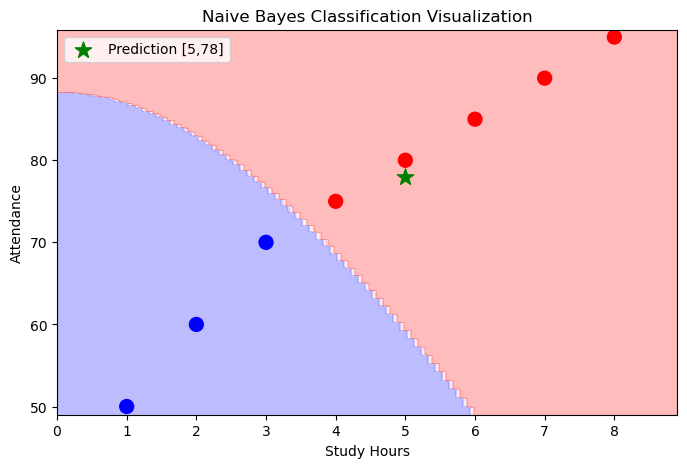

In [19]:
# Naive Bayes
# 11. Naive Bayes Classifier
# អ្វីដែលវាធ្វើ: ទាយ label ដោយ probability និង assumption ថា features independent។
# ឧទាហរណ៍: Email spam filtering, text classification.
# គន្លឹះ: ងាយប្រើ, លឿន, ល្អសម្រាប់ text data.
# Example classification data
X_class = np.array([[1,50],[2,60],[3,70],[4,75],[5,80],[6,85],[7,90],[8,95]])
y_class = np.array([0,0,0,1,1,1,1,1])  # 0=Fail, 1=Pass

# Train Naive Bayes Classifier
nb = GaussianNB()
nb.fit(X_class, y_class)

# Prediction example
pred_example = nb.predict([[5,78]])
print("Naive Bayes Prediction [5,78]:", pred_example)

# Visualization (decision boundary)
x_min, x_max = X_class[:,0].min()-1, X_class[:,0].max()+1
y_min, y_max = X_class[:,1].min()-1, X_class[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
Z = nb.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
plt.scatter(X_class[:,0], X_class[:,1], c=y_class, cmap='bwr', s=100)
plt.scatter([5], [78], color='green', s=150, marker='*', label='Prediction [5,78]')
plt.title("Naive Bayes Classification Visualization")
plt.xlabel("Study Hours")
plt.ylabel("Attendance")
plt.legend()
plt.show()